In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
from phik import resources, report
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz
from tqdm import tqdm
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

### **1. Загрузка и осмотр данных**

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/nikitaLar-collab/Datasets/refs/heads/main/athletes.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB


In [4]:
df.describe()

,id,height,weight,gold,silver,bronze
count,1.153800e+04,11208.000000,10879.000000,11538.000000,11538.000000,11538.000000
mean,4.999885e+08,1.766282,72.068205,0.057722,0.056769,0.061016
std,2.908648e+08,0.112719,16.177334,0.255910,0.239147,0.243320
min,1.834700e+04,1.210000,31.000000,0.000000,0.000000,0.000000
25%,2.450997e+08,1.690000,60.000000,0.000000,0.000000,0.000000
50%,5.002011e+08,1.760000,70.000000,0.000000,0.000000,0.000000
75%,7.539874e+08,1.840000,81.000000,0.000000,0.000000,0.000000
max,9.999878e+08,2.210000,170.000000,5.000000,2.000000,2.000000


In [5]:
df.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,10/17/69,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,9/23/86,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,5/27/92,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1/2/91,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,11/26/90,1.81,71.0,cycling,0,0,0


In [6]:
# Проверка на полные дубликаты в датасете с дубликатами
total_duplicates = df.duplicated().sum()
print(f"Полных дубликатов: {total_duplicates}")

Полных дубликатов: 0


In [7]:
# Проверка частичных дубликатов по id
id_duplicates = df.duplicated(subset=['id']).sum()
print(f"Дубликатов по id: {id_duplicates}")

Дубликатов по id: 0


In [8]:
df['sex'].value_counts()

sex
male      6333
female    5205
Name: count, dtype: int64

Семантические дубликаты в колонке `sex` отсутствуют

В колонке `sport` применим метод fuzzywuzzy для сравнения значений строк, чтобы найти семантические дубликаты

In [9]:
df['sport'].value_counts()

sport
athletics            2363
aquatics             1445
football              611
rowing                547
cycling               525
hockey                432
judo                  392
shooting              390
volleyball            384
sailing               380
handball              363
wrestling             353
canoe                 331
gymnastics            324
rugby sevens          300
basketball            288
boxing                286
weightlifting         258
fencing               246
equestrian            222
tennis                196
badminton             172
table tennis          172
taekwondo             128
archery               128
golf                  120
triathlon             110
modern pentathlon      72
Name: count, dtype: int64

In [10]:
def find_duplicates_partial(series, threshold=80):
    """
    Находит группы дубликатов в Series.
    Возвращает DataFrame с колонками: 'Оригинал', 'Дубликат', 'Score'.
    ИЛИ использует графы для кластеризации.
    """
    # Очищаем от NaN и дублирующихся индексов
    items = series.dropna().unique().tolist()
    duplicates = []
    
    # Перебираем все пары (если данных много, лучше разбить на блоки)
    for str1, str2 in tqdm(combinations(items, 2), desc="Сравнение строк"):
        score = fuzz.partial_ratio(str(str1), str(str2))
        if score >= threshold:
            duplicates.append((str1, str2, score))
            
    return pd.DataFrame(duplicates, columns=['Строка 1', 'Строка 2', 'Score'])

In [11]:
dupes_df = find_duplicates_partial(df['sport'], threshold=85)
print(dupes_df)

Сравнение строк: 378it [00:00, 139404.46it/s]

       Строка 1 Строка 2  Score
0  table tennis   tennis    100


Метод fuzzywuzzy нашёл похожие названия: table tennis и tennis, однако семантическими дубликатами они не являются. Семантических дубилкатов в колонке `sport` нет

Выводы по осмотру данных:
1. Имеются пропуски в колонках: dob, height, weigh

2. Колонка dob содержит информацию о дате рождения, но имеет неправильный формат для перевода в временной тип данных.

3. Частичные и полные дубликаты отсутствуют

4. Семантические дубликаты отсутствуют

###  **2. Изменение типа данных**

In [12]:
def fix_century(date_series, ):
    cutoff_year = 2026
    dates = pd.to_datetime(date_series, format="%m/%d/%y", errors='coerce')
    # Корректируем год для дат, которые оказались в будущем
    mask = dates.dt.year > cutoff_year
    dates[mask] = dates[mask] - pd.DateOffset(years=100)
    return dates



In [13]:
# Применяем преобразование
df['dob'] = fix_century(df['dob'])

In [14]:
df.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze
0,736041664,A Jesus Garcia,ESP,male,1969-10-17,1.72,64.0,athletics,0,0,0
1,532037425,A Lam Shin,KOR,female,1986-09-23,1.68,56.0,fencing,0,0,0
2,435962603,Aaron Brown,CAN,male,1992-05-27,1.98,79.0,athletics,0,0,1
3,521041435,Aaron Cook,MDA,male,1991-01-02,1.83,80.0,taekwondo,0,0,0
4,33922579,Aaron Gate,NZL,male,1990-11-26,1.81,71.0,cycling,0,0,0


In [15]:
print(f"Тип колонки: {df['dob'].dtype}")
print(f"Диапазон: {df['dob'].min()} — {df['dob'].max()}")
print(f"Пропусков (NaT): {df['dob'].isna().sum()}")


Тип колонки: datetime64[ns]
Диапазон: 1954-05-20 00:00:00 — 2002-11-26 00:00:00
Пропусков (NaT): 1


### **3. Создание колонки возраста**

Создадим новую колонку возраста по колонке даты рождения.

In [16]:
df = df.copy()

In [17]:
def add_age_column(df, col, today_date="2026-01-01"):
    today = pd.Timestamp(today_date)
    birth_date = df[col]
    age = today.year - birth_date.dt.year
    had_birthday = (today.month > birth_date.dt.month) | ((today.month == birth_date.dt.month) & (today.day >= birth_date.dt.day))
    df['age'] = age - (~had_birthday).astype(int)
    
    return df

In [18]:
df = add_age_column(df, 'dob')

In [19]:
df.head()

,id,name,nationality,sex,dob,height,weight,sport,gold,silver,bronze,age
0,736041664,A Jesus Garcia,ESP,male,1969-10-17,1.72,64.0,athletics,0,0,0,56.0
1,532037425,A Lam Shin,KOR,female,1986-09-23,1.68,56.0,fencing,0,0,0,39.0
2,435962603,Aaron Brown,CAN,male,1992-05-27,1.98,79.0,athletics,0,0,1,33.0
3,521041435,Aaron Cook,MDA,male,1991-01-02,1.83,80.0,taekwondo,0,0,0,34.0
4,33922579,Aaron Gate,NZL,male,1990-11-26,1.81,71.0,cycling,0,0,0,35.0


### **4. Поиск и диагностика пропусков в данных**

<Axes: >

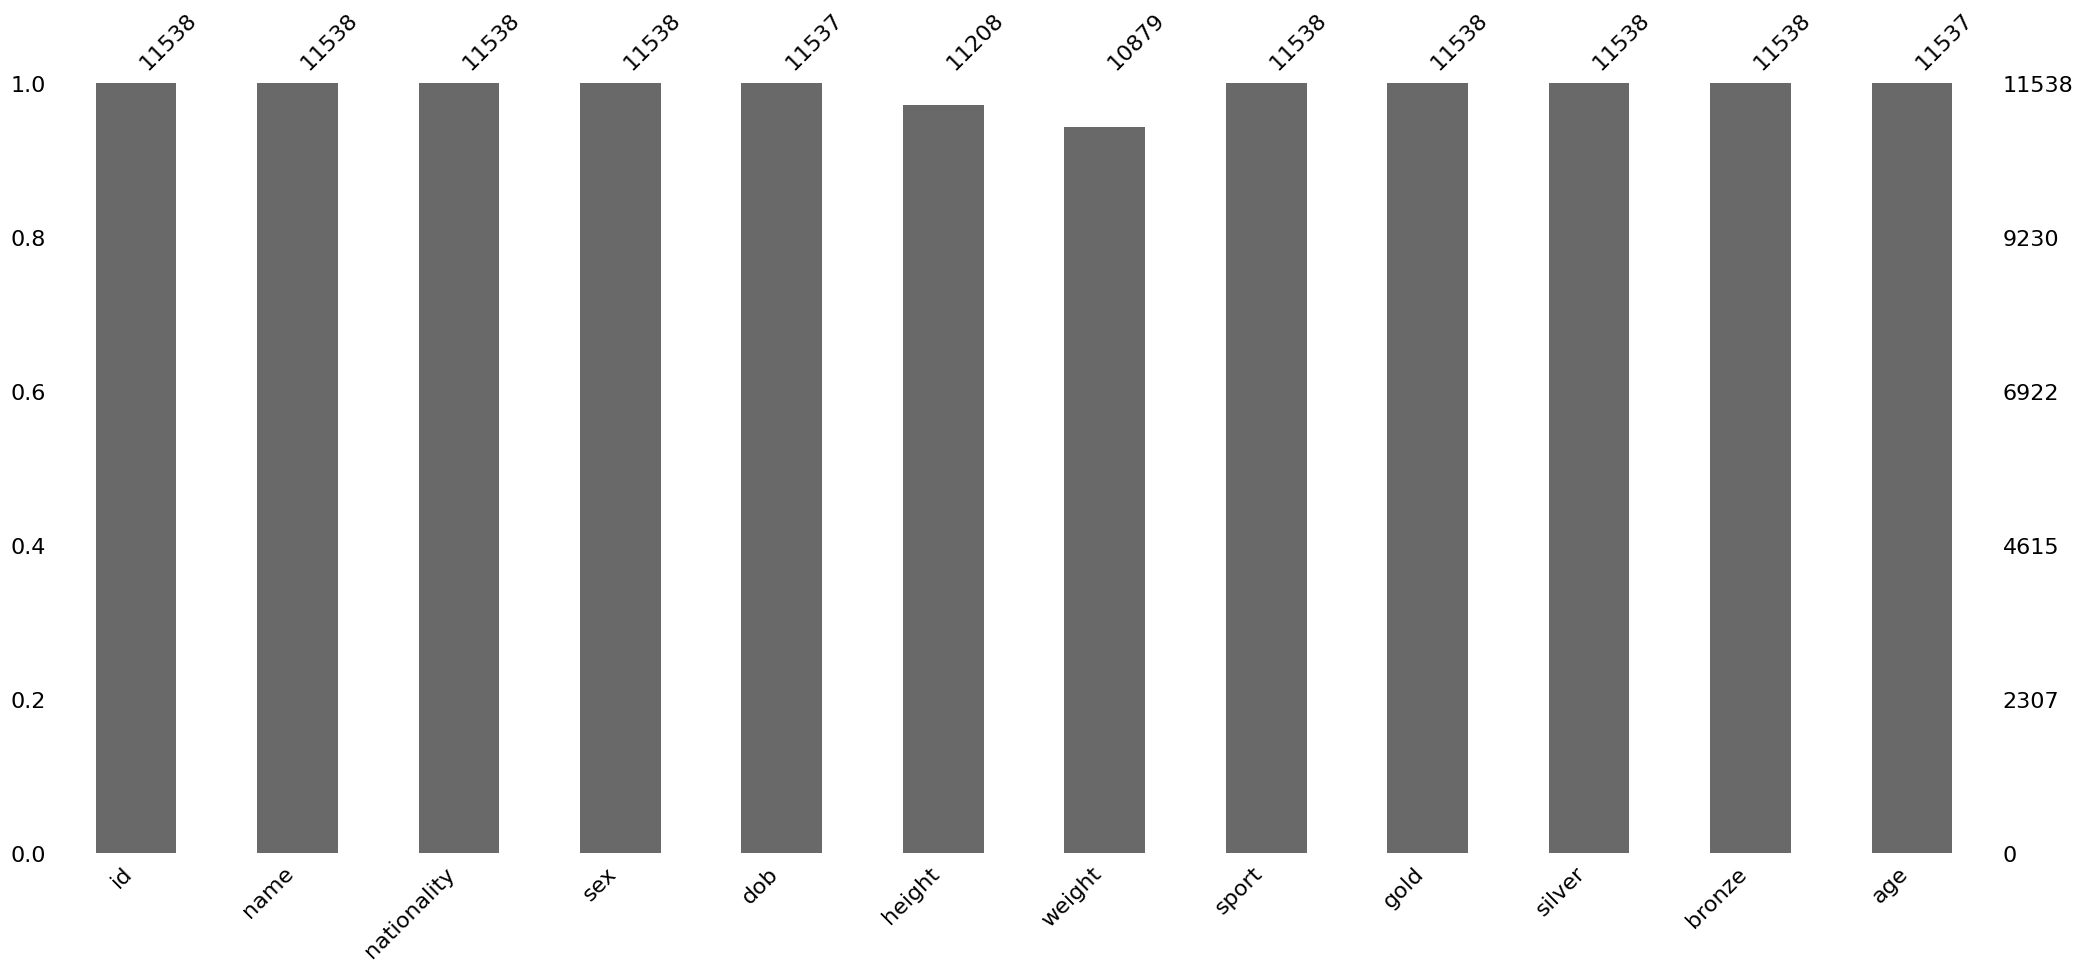

In [20]:
msno.bar(df)

In [21]:
# Статистика пропусков
missing_stats = pd.DataFrame({
    'Колонка': df.columns,
    'Пропусков': df.isna().sum().values,
    'Доля (%)': (df.isna().mean() * 100).round(1).values
}).sort_values('Доля (%)', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)
missing_stats

,Колонка,Пропусков,Доля (%)
0,weight,659,5.7
1,height,330,2.9
2,id,0,0.0
3,name,0,0.0
4,sex,0,0.0
5,nationality,0,0.0
6,dob,1,0.0
7,sport,0,0.0
8,gold,0,0.0
9,silver,0,0.0


Основная доля пропусков находится в колонках `height` и `weight`. Колонки `dob` и `age` содержат по одному пропуску, в дальнейшем эти два пропуска просто удалим

<Axes: >

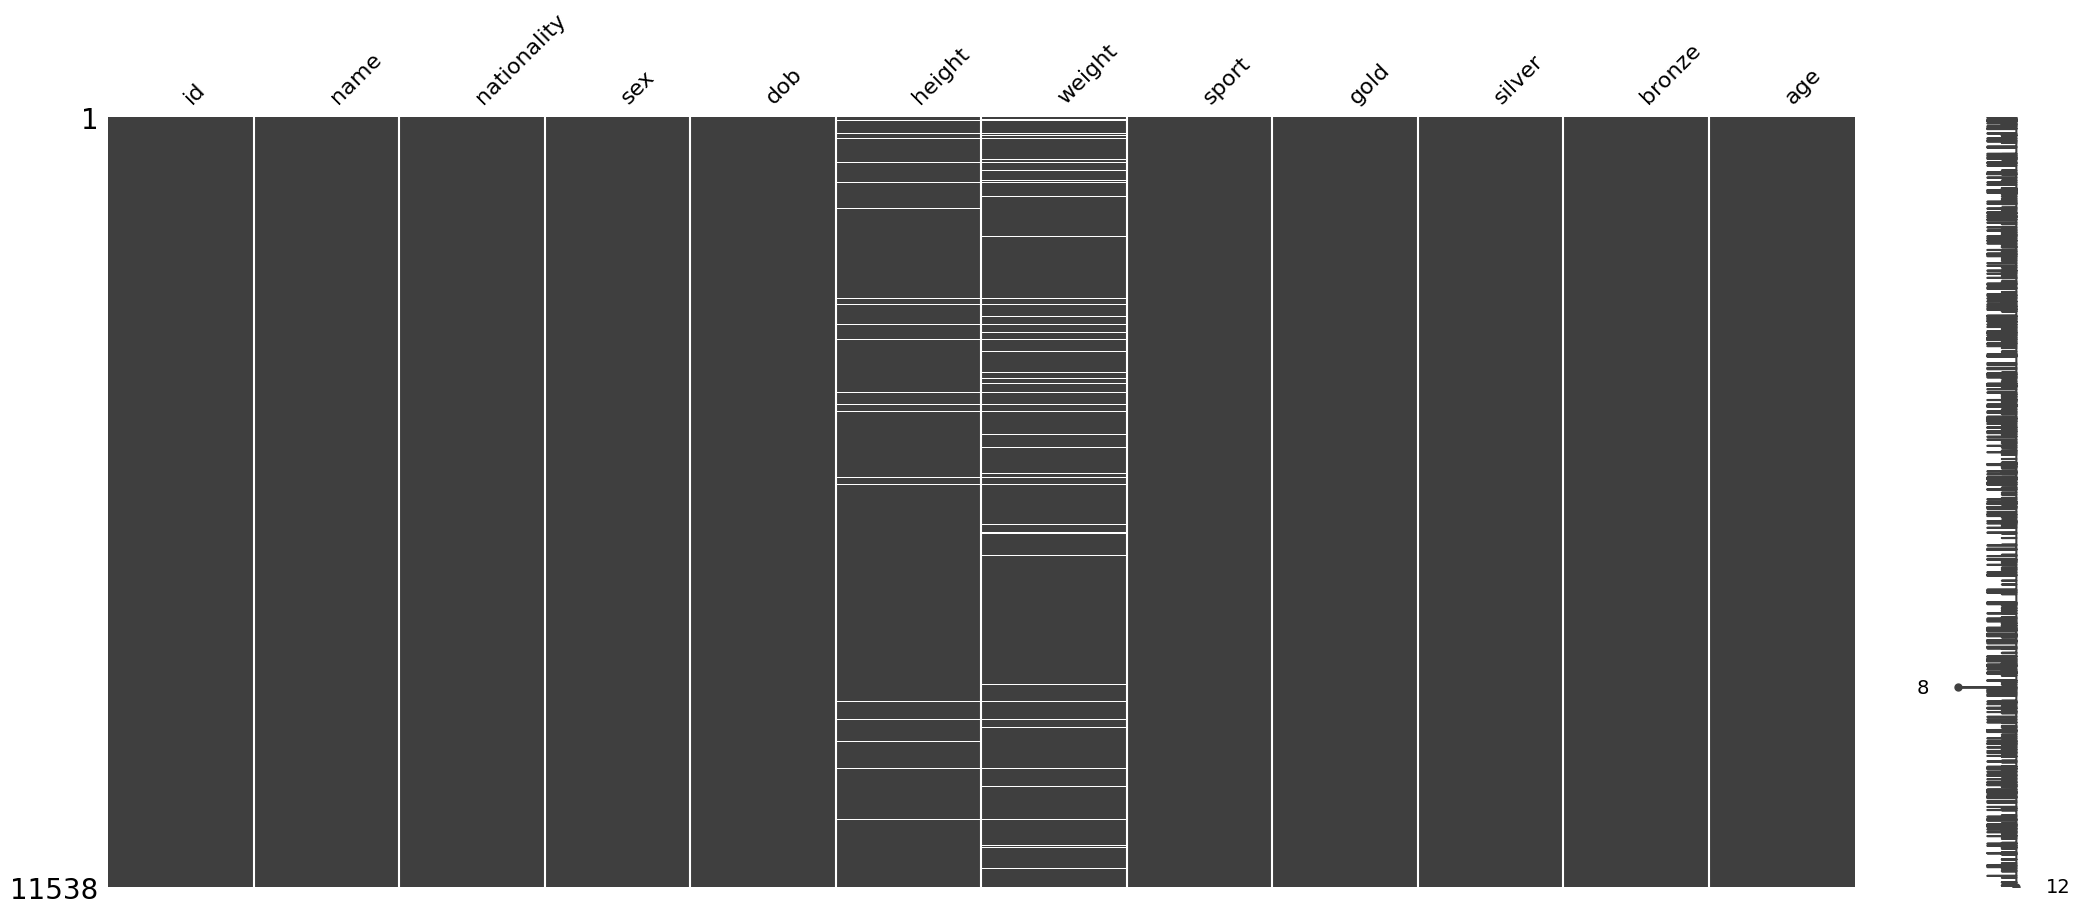

In [22]:
msno.matrix(df)

Видна совпадение пропусков в колонках `height` и `weight`

<Axes: >

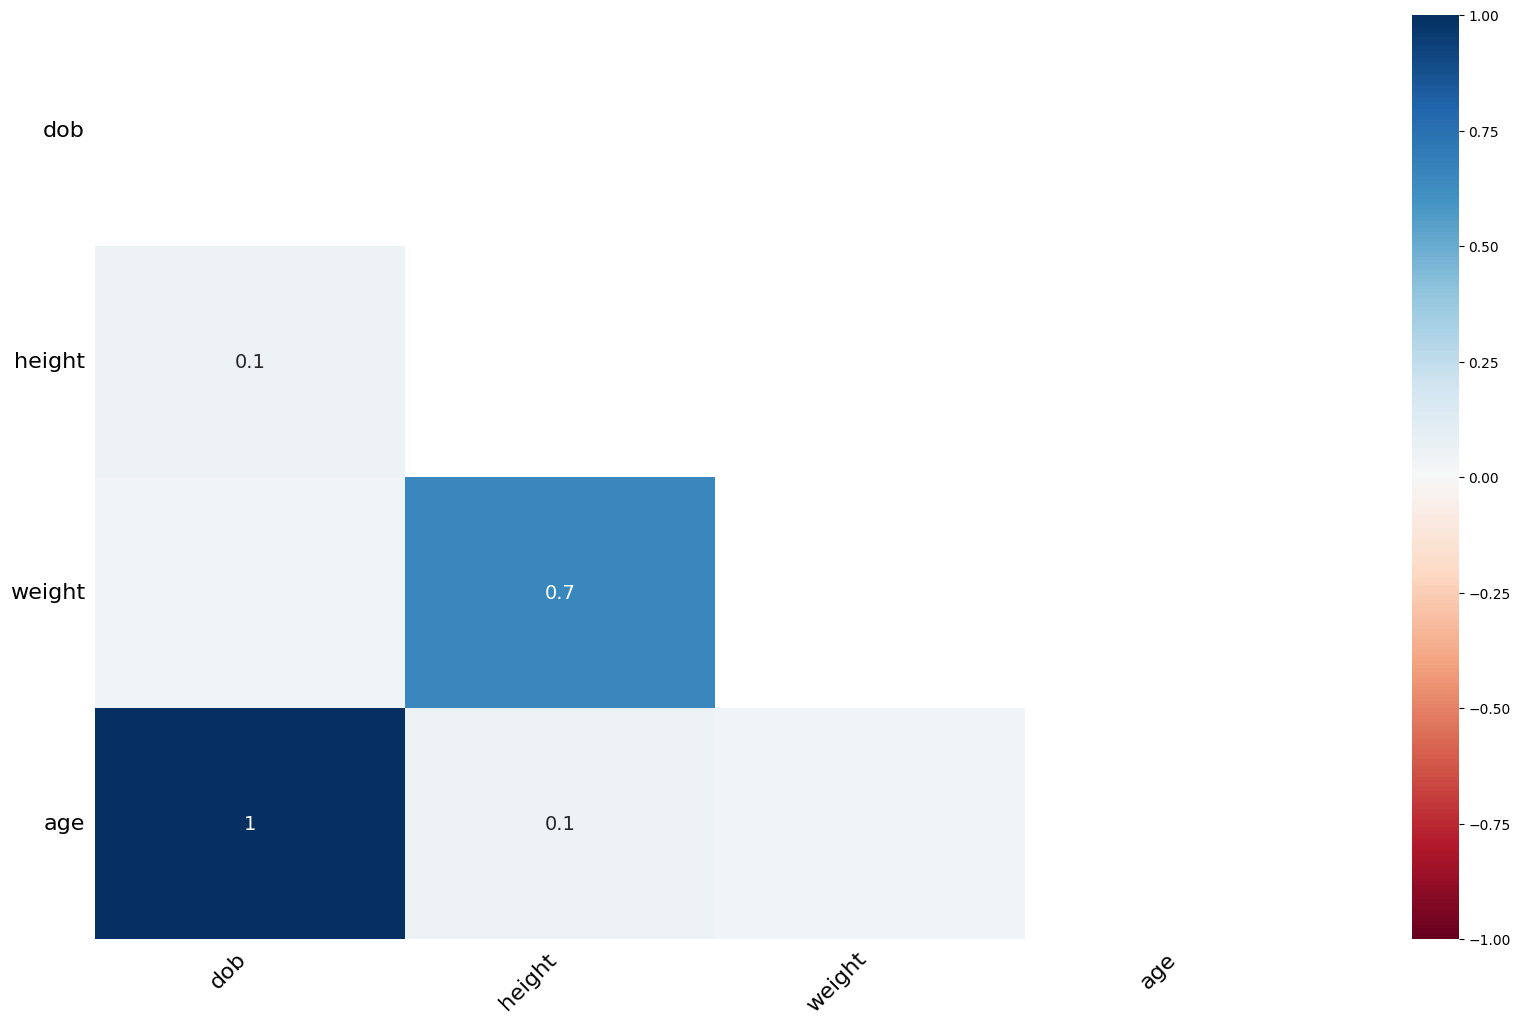

In [23]:
msno.heatmap(df)

In [24]:
df['height_is_na'] = df['height'].isna()
df['weight_is_na'] = df['weight'].isna()

Создали колонки-флаги наличия пропуска `height_is_na` и `weight_is_na`, чтобы найти взаимосвязь пропусков со значениями других колонок

d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\phik\data_quality.py:59: UserWarning: The number of unique values of variable dob is large: 5595. Are you sure this is not an interval variable? Analysis for pairs of variables including dob can be slow.
  warnings.warn(


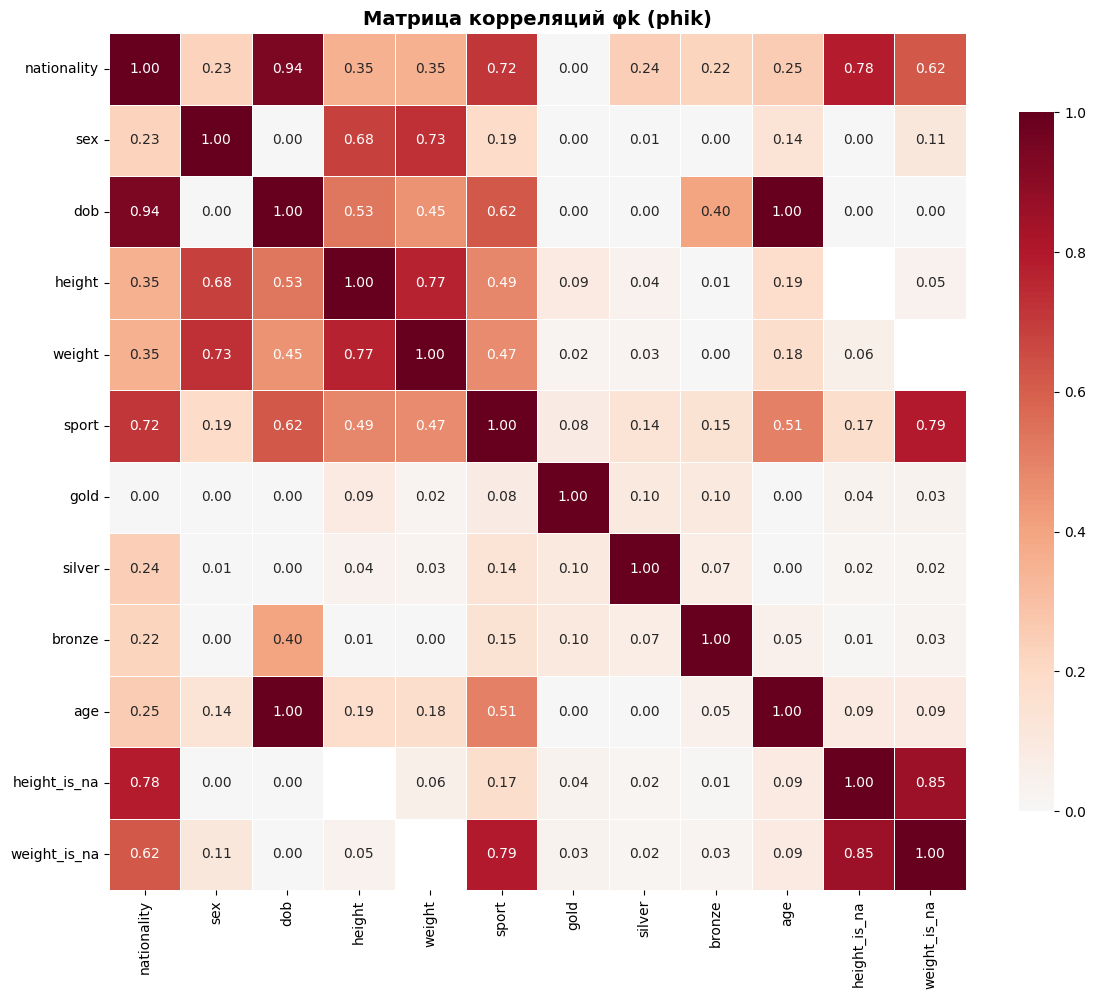

In [25]:
# Определяем интервальные (непрерывные) переменные
interval_cols = ['height',
    'weight',
    'gold',
    'silver',
    'bronze',
    'age'
    ]

# Расчёт матрицы phik с явным указанием интервальных переменных
phik_matrix = df.drop(['id', 'name'], axis=1).phik_matrix(interval_cols=interval_cols, )

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Матрица корреляций φk (phik)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Анализ корреляций индикаторов пропусков
print("📊 Анализ связей индикаторов пропусков:\n")

# Извлекаем корреляции для индикаторов пропусков
na_indicators = ['height_is_na', 'weight_is_na']
other_vars = ['nationality', 'sex', 'sport', 'age']

for indicator in na_indicators:
    print(f"\n{indicator.replace('_is_na', '').upper()}:")
    correlations = phik_matrix.loc[other_vars, indicator].sort_values(ascending=False)
    for var, corr in correlations.items():
        if abs(corr) > 0.2:
            print(f"   {var}: φk = {corr:.3f} {'⚠️' if abs(corr) > 0.3 else ''}")

    # Проверяем, есть ли значимые корреляции
    max_corr = correlations.abs().max()
    if max_corr > 0.3:
        print(f"   → ВЫВОД: MAR (пропуски зависят от наблюдаемых переменных)")
    elif max_corr > 0.2:
        print(f"   → ВЫВОД: Возможно MAR")
    else:
        print(f"   → ВЫВОД: Возможно MCAR (нет явных связей)")

📊 Анализ связей индикаторов пропусков:


HEIGHT:
   nationality: φk = 0.782 ⚠️
   → ВЫВОД: MAR (пропуски зависят от наблюдаемых переменных)

WEIGHT:
   sport: φk = 0.793 ⚠️
   nationality: φk = 0.624 ⚠️
   → ВЫВОД: MAR (пропуски зависят от наблюдаемых переменных)


Так как есть взоимосвязь колонок `height` и `weight` с колонкой возраста, необходимо создать категориальную колонку возраста `age_cat`

In [27]:
age_bins = [0, 18, 30, 45, 60, 75, 90, 120]
age_labels = [
    'дети и подростки',
    'молодёжь', 
    'зрелый возраст',
    'средний возраст',
    'пожилые',
    'старческий возраст',
    'долгожители'
]

df['age_cat'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

Заполним пропуски в колокнах `height` и `weight` медианой сгруппированной по полу, возрасту и виду спорта

In [28]:
df['height'] = df.groupby(['sex', 'age_cat', 'sport'], observed=True)['height'].transform(lambda x: x.fillna(x.median()))

d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [29]:
df['weight'] = df.groupby(['sex', 'age_cat', 'sport'], observed=True)['weight'].transform(lambda x: x.fillna(x.median()))

d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Data_science\miniconda3\envs\analyst\Lib\site-packag

In [30]:
# Статистика пропусков
missing_stats = pd.DataFrame({
    'Колонка': df.columns,
    'Пропусков': df.isna().sum().values,
    'Доля (%)': (df.isna().mean() * 100).round(1).values
}).sort_values('Доля (%)', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)
missing_stats

,Колонка,Пропусков,Доля (%)
0,weight,288,2.5
1,name,0,0.0
2,id,0,0.0
3,nationality,0,0.0
4,sex,0,0.0
5,dob,1,0.0
6,height,2,0.0
7,sport,0,0.0
8,gold,0,0.0
9,silver,0,0.0


После группового заполнения остались пропуски в колонке `weight`. Попробуем повторить групповое заполнение, только уже по более крупной выборке. Сначала по полу и виду спорта, затем только по полу

In [31]:
df['weight'] = df.groupby(['sex', 'sport'], observed=True)['weight'].transform(lambda x: x.fillna(x.median()))

d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\Data_science\miniconda3\envs\analyst\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [32]:
df['weight'].isnull().sum()

np.int64(286)

In [33]:
df['weight'] = df.groupby(['sex'], observed=True)['weight'].transform(lambda x: x.fillna(x.median()))

In [34]:
# Статистика пропусков
missing_stats = pd.DataFrame({
    'Колонка': df.columns,
    'Пропусков': df.isna().sum().values,
    'Доля (%)': (df.isna().mean() * 100).round(1).values
}).sort_values('Доля (%)', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)
missing_stats

,Колонка,Пропусков,Доля (%)
0,id,0,0.0
1,name,0,0.0
2,nationality,0,0.0
3,sex,0,0.0
4,dob,1,0.0
5,height,2,0.0
6,weight,0,0.0
7,sport,0,0.0
8,gold,0,0.0
9,silver,0,0.0


После группового заполнения остались только единичные пропуски в четырёх колонках, можно спокойно удалить строки с этими пропусками

In [35]:
df = df.dropna(subset=['dob'])
df = df.dropna(subset=['age'])
df = df.dropna(subset=['age_cat'])
df = df.dropna(subset=['height'])


In [36]:
# Статистика пропусков
missing_stats = pd.DataFrame({
    'Колонка': df.columns,
    'Пропусков': df.isna().sum().values,
    'Доля (%)': (df.isna().mean() * 100).round(1).values
}).sort_values('Доля (%)', ascending=False)
missing_stats = missing_stats.reset_index(drop=True)
missing_stats

,Колонка,Пропусков,Доля (%)
0,id,0,0.0
1,name,0,0.0
2,nationality,0,0.0
3,sex,0,0.0
4,dob,0,0.0
5,height,0,0.0
6,weight,0,0.0
7,sport,0,0.0
8,gold,0,0.0
9,silver,0,0.0


Вывод:
1. Мы проверили взаимосвязи пропусков в данных
2. Определили категорию пропусков MAR для колонок `height` и `weight`
3. Нашли единичный пропуск в колонке `dob`
4. Применили групповое заполнение для `height` и `weight`

### **5. Создание модели логистической регрессии**

Изменим значения колонки `sex` на 1 и 0

In [37]:
df['sex'] = df['sex'].replace({'male': 1, 'female': 0})

C:\Users\Никита\AppData\Local\Temp\ipykernel_10980\668641564.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['sex'].replace({'male': 1, 'female': 0})


In [38]:
X = df[['nationality', 'height', 'weight', 'sport', 'age']]
y = df['sex']

In [39]:
le = LabelEncoder()

In [40]:
le.fit(X['nationality'])

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](207,)","['AFG','ALB','ALG',...,'YEM','ZAM','ZIM']"


In [41]:
le.classes_

array(['AFG', 'ALB', 'ALG', 'AND', 'ANG', 'ANT', 'ARG', 'ARM', 'ARU',
       'ASA', 'AUS', 'AUT', 'AZE', 'BAH', 'BAN', 'BAR', 'BDI', 'BEL',
       'BEN', 'BER', 'BHU', 'BIH', 'BIZ', 'BLR', 'BOL', 'BOT', 'BRA',
       'BRN', 'BRU', 'BUL', 'BUR', 'CAF', 'CAM', 'CAN', 'CAY', 'CGO',
       'CHA', 'CHI', 'CHN', 'CIV', 'CMR', 'COD', 'COK', 'COL', 'COM',
       'CPV', 'CRC', 'CRO', 'CUB', 'CYP', 'CZE', 'DEN', 'DJI', 'DMA',
       'DOM', 'ECU', 'EGY', 'ERI', 'ESA', 'ESP', 'EST', 'ETH', 'FIJ',
       'FIN', 'FRA', 'FSM', 'GAB', 'GAM', 'GBR', 'GBS', 'GEO', 'GEQ',
       'GER', 'GHA', 'GRE', 'GRN', 'GUA', 'GUI', 'GUM', 'GUY', 'HAI',
       'HKG', 'HON', 'HUN', 'INA', 'IND', 'IOA', 'IRI', 'IRL', 'IRQ',
       'ISL', 'ISR', 'ISV', 'ITA', 'IVB', 'JAM', 'JOR', 'JPN', 'KAZ',
       'KEN', 'KGZ', 'KIR', 'KOR', 'KOS', 'KSA', 'LAO', 'LAT', 'LBA',
       'LBR', 'LCA', 'LES', 'LIB', 'LIE', 'LTU', 'LUX', 'MAD', 'MAR',
       'MAS', 'MAW', 'MDA', 'MDV', 'MEX', 'MGL', 'MHL', 'MKD', 'MLI',
       'MLT', 'MNE',

In [42]:
le.transform(['AFG', 'ALB', 'ALG', 'AND', 'ANG', 'ANT', 'ARG', 'ARM', 'ARU',
       'ASA', 'AUS', 'AUT', 'AZE', 'BAH', 'BAN', 'BAR', 'BDI', 'BEL',
       'BEN', 'BER', 'BHU', 'BIH', 'BIZ', 'BLR', 'BOL', 'BOT', 'BRA',
       'BRN', 'BRU', 'BUL', 'BUR', 'CAF', 'CAM', 'CAN', 'CAY', 'CGO',
       'CHA', 'CHI', 'CHN', 'CIV', 'CMR', 'COD', 'COK', 'COL', 'COM',
       'CPV', 'CRC', 'CRO', 'CUB', 'CYP', 'CZE', 'DEN', 'DJI', 'DMA',
       'DOM', 'ECU', 'EGY', 'ERI', 'ESA', 'ESP', 'EST', 'ETH', 'FIJ',
       'FIN', 'FRA', 'FSM', 'GAB', 'GAM', 'GBR', 'GBS', 'GEO', 'GEQ',
       'GER', 'GHA', 'GRE', 'GRN', 'GUA', 'GUI', 'GUM', 'GUY', 'HAI',
       'HKG', 'HON', 'HUN', 'INA', 'IND', 'IOA', 'IRI', 'IRL', 'IRQ',
       'ISL', 'ISR', 'ISV', 'ITA', 'IVB', 'JAM', 'JOR', 'JPN', 'KAZ',
       'KEN', 'KGZ', 'KIR', 'KOR', 'KOS', 'KSA', 'LAO', 'LAT', 'LBA',
       'LBR', 'LCA', 'LES', 'LIB', 'LIE', 'LTU', 'LUX', 'MAD', 'MAR',
       'MAS', 'MAW', 'MDA', 'MDV', 'MEX', 'MGL', 'MHL', 'MKD', 'MLI',
       'MLT', 'MNE', 'MON', 'MOZ', 'MRI', 'MTN', 'MYA', 'NAM', 'NCA',
       'NED', 'NEP', 'NGR', 'NIG', 'NOR', 'NRU', 'NZL', 'OMA', 'PAK',
       'PAN', 'PAR', 'PER', 'PHI', 'PLE', 'PLW', 'PNG', 'POL', 'POR',
       'PRK', 'PUR', 'QAT', 'ROT', 'ROU', 'RSA', 'RUS', 'RWA', 'SAM',
       'SEN', 'SEY', 'SIN', 'SKN', 'SLE', 'SLO', 'SMR', 'SOL', 'SOM',
       'SRB', 'SRI', 'SSD', 'STP', 'SUD', 'SUI', 'SUR', 'SVK', 'SWE',
       'SWZ', 'SYR', 'TAN', 'TGA', 'THA', 'TJK', 'TKM', 'TLS', 'TOG',
       'TPE', 'TTO', 'TUN', 'TUR', 'TUV', 'UAE', 'UGA', 'UKR', 'URU',
       'USA', 'UZB', 'VAN', 'VEN', 'VIE', 'VIN', 'YEM', 'ZAM', 'ZIM']) # пример расшифровки

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [43]:
X['nationality'] = le.transform(X['nationality'])

C:\Users\Никита\AppData\Local\Temp\ipykernel_10980\1305971567.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['nationality'] = le.transform(X['nationality'])


In [44]:
le.fit(X['sport'])

Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Holds the label for each class.","ndarray[object](28,)","['aquatics','archery','athletics',...,'volleyball','weightlifting', 'wrestling']"


In [45]:
le.classes_

array(['aquatics', 'archery', 'athletics', 'badminton', 'basketball',
       'boxing', 'canoe', 'cycling', 'equestrian', 'fencing', 'football',
       'golf', 'gymnastics', 'handball', 'hockey', 'judo',
       'modern pentathlon', 'rowing', 'rugby sevens', 'sailing',
       'shooting', 'table tennis', 'taekwondo', 'tennis', 'triathlon',
       'volleyball', 'weightlifting', 'wrestling'], dtype=object)

In [46]:
le.transform(['aquatics', 'archery', 'athletics', 'badminton', 'basketball',
       'boxing', 'canoe', 'cycling', 'equestrian', 'fencing', 'football',
       'golf', 'gymnastics', 'handball', 'hockey', 'judo',
       'modern pentathlon', 'rowing', 'rugby sevens', 'sailing',
       'shooting', 'table tennis', 'taekwondo', 'tennis', 'triathlon',
       'volleyball', 'weightlifting', 'wrestling']) # пример расшифровки

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27])

In [47]:
X['sport'] = le.transform(X['sport'])

C:\Users\Никита\AppData\Local\Temp\ipykernel_10980\345374900.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['sport'] = le.transform(X['sport'])


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
model = LogisticRegression()
model.fit(X_train, y_train)
predictions = model.predict_proba(X_test)

In [50]:
predictions[:5] # посмотрим как выглядят наши предсказания

array([[0.49860987, 0.50139013],
       [0.55438543, 0.44561457],
       [0.06458889, 0.93541111],
       [0.02810916, 0.97189084],
       [0.36069767, 0.63930233]])

In [51]:
model.predict(X_test)

array([1, 0, 1, ..., 1, 0, 1], shape=(2308,))

In [52]:
print(model.score(X_train, y_train))
print(model.score(X_test,y_test))

0.7850021673168617
0.7915944540727903


### **6. Построение ROC-кривой**

In [53]:
fpr, tpr, thresholds = roc_curve(y_test, predictions[:,1])

Text(0, 0.5, 'Доля ложноотрицательных классификаций')

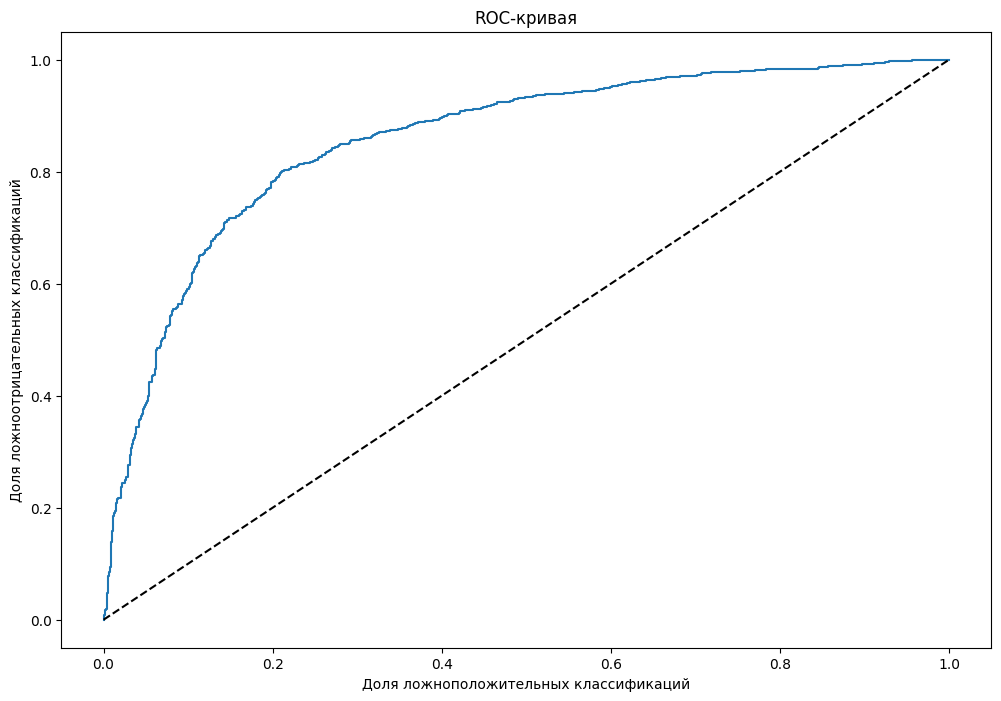

In [54]:
plt.figure(figsize=(12, 8))
plt.plot( fpr, tpr )
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC-кривая')
plt.xlabel('Доля ложноположительных классификаций')
plt.ylabel('Доля ложноотрицательных классификаций')

### **7. Вычисление ROC_AUC**

In [55]:
roc_auc_score(y_test, predictions[:, 1])

0.8561937705763658

### **8. Подсчет метрик TPR, FPR**

In [56]:
def calculate_roc_simple(y_true, y_scores, num_thresholds=100):
    thresholds = np.linspace(0, 1, num_thresholds)
    
    fpr_list = []
    tpr_list = []
    
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    
    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        FP = np.sum((y_pred == 1) & (y_true == 0))
        
        TPR = TP / P if P > 0 else 0
        FPR = FP / N if N > 0 else 0
        
        tpr_list.append(TPR)
        fpr_list.append(FPR)
    
    return np.array(fpr_list), np.array(tpr_list), thresholds

# Использование
fpr2, tpr2, thresholds2 = calculate_roc_simple(y_test, predictions[:,1])

Text(0, 0.5, 'Доля ложноотрицательных классификаций')

<Figure size 1200x800 with 0 Axes>

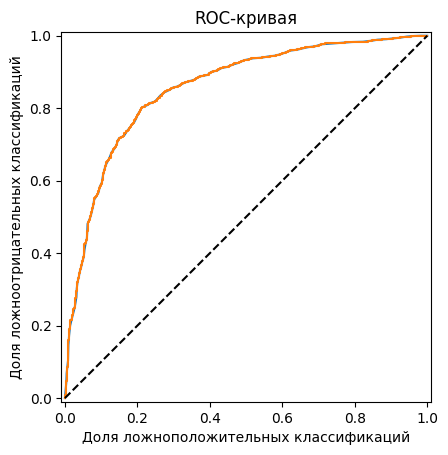

In [57]:
plt.figure(figsize=(12, 8))
RocCurveDisplay(fpr=fpr2, tpr=tpr2).plot()
plt.plot( fpr, tpr )
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC-кривая')
plt.xlabel('Доля ложноположительных классификаций')
plt.ylabel('Доля ложноотрицательных классификаций')

ROC-кривая построенная по вручную рассчитанным метрикам tpr, fpr совпадает с ROC-кривой построенной с использованием sklearn

### **9. График Precision-Recall**

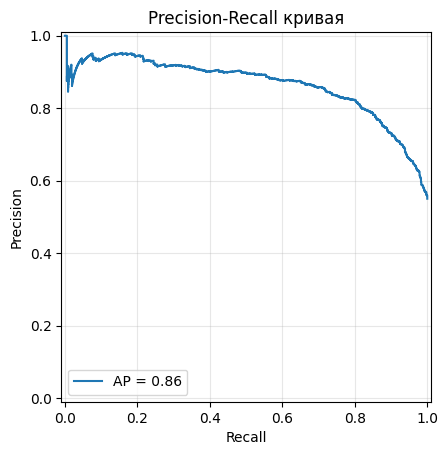

In [58]:
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, auc
precisions, recalls, thresholds = precision_recall_curve(y_test, predictions[:,1])

# Строим график
PrecisionRecallDisplay(
    precision=precisions,
    recall=recalls,
    average_precision=auc(recalls, precisions)  # площадь под PR-кривой
).plot()

plt.title('Precision-Recall кривая')
plt.grid(True, alpha=0.3)
plt.show()

### **10. Расчёт значения ROC-AUC**

In [59]:
roc_auc_score(y_test, predictions[:, 1])

0.8561937705763658

### **11. Вывод**

1. Значение ROC-AUC равно 0.86, что говорит о хорошем качестве классификатора
2. Кривая ROC стремится к правому верхнему углу, что говорит о хорошей модели
3. Если ROC кривая ниже диагонали, это значит что модель  неправильно классифицирует каждую точку. На самом деле это не плохо, потому что нам нужно только обратить все положительные и отрицательные прогнозы и получить результат